# Dự Đoán Giá Cổ Phiếu VIC Sử Dụng LTSF-Linear Models

## Mục tiêu:
- Dự đoán giá đóng cửa VIC cho 5 ngày tiếp theo
- Sử dụng dữ liệu 5, 30, 120, 480 ngày trước tương ứng
- Implement LTSF-Linear models: Linear, DLinear, NLinear
- So sánh hiệu suất với các baseline models



## 1. Import Libraries và Load Data


In [1]:

!pip install dash dash-bootstrap-components plotly pyngrok diskcache multiprocess

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 61.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.9 MB/s eta 0:00:00


In [2]:
!pip install -U transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 86.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 78.0 MB/s eta 0:00:00:00:01
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.2
    Uninstalling tokenizers-0.21.2:
      Successfully uninstalled tokenizers-0.21.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.53.3
    Uninstalling transformers-4.53.3:
      Successfully uninstalled transformers-4.53.3


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler

import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import random
import numpy as np
import torch
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
print(f"Device available: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

Device available: CUDA


In [4]:
# --- 1. Hàm thiết lập Seed (Để kết quả cố định) ---
def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Thiết lập seed trước khi chạy
seed_everything(42)
print("--> Đã thiết lập Random Seed: 42")

--> Đã thiết lập Random Seed: 42


In [5]:
df = pd.read_csv('/kaggle/input/aio-2025-linear-forecasting-challenge/FPT_train.csv')
print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")

df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time').reset_index(drop=True)

print("\nFirst few rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe())

Dataset shape: (1149, 7)
Date range: 2020-08-03 to 2025-03-10

First few rows:


,time,open,high,low,close,volume,symbol
0,2020-08-03,19.07,19.63,19.03,19.63,1392200,FPT
1,2020-08-04,19.89,20.01,19.76,19.91,1051310,FPT
2,2020-08-05,19.89,20.16,19.78,20.10,1328520,FPT
3,2020-08-06,20.10,20.21,19.97,20.01,1153660,FPT
4,2020-08-07,20.01,20.44,20.01,20.14,1283690,FPT



Data types:
time      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
symbol            object
dtype: object

Basic statistics:


,time,open,high,low,close,volume
count,1149,1149.000000,1149.000000,1149.000000,1149.000000,1.149000e+03
mean,2022-11-18 03:30:32.898172416,61.965666,62.625483,61.349721,61.999182,2.444857e+06
min,2020-08-03 00:00:00,19.070000,19.630000,19.030000,19.630000,2.219660e+05
25%,2021-09-24 00:00:00,46.690000,47.180000,46.110000,46.640000,1.244928e+06
50%,2022-11-16 00:00:00,51.340000,51.860000,50.890000,51.290000,1.984701e+06
75%,2024-01-09 00:00:00,71.730000,72.470000,71.060000,71.580000,3.062690e+06
max,2025-03-10 00:00:00,132.870000,134.500000,132.260000,133.040000,1.372370e+07
std,NaN,29.457209,29.700736,29.221866,29.462158,1.821708e+06


## 2. Khám Phá Dữ Liệu và Thiết Kế Target Variables


In [6]:
# === BƯỚC 2: FEATURE CREATION & MISSING VALUE DETECTION ===

# Tạo essential features
print("1. Tạo essential features:")
# df['daily_return'] = df['close'].pct_change()
# df['close_log'] = np.log(df['close'])
print(" - daily_return: phần trăm thay đổi hàng ngày")
print(" - close_log: log giá đóng cửa")

# Kiểm tra missing values cho TẤT CẢ các cột
missing_info = df.isnull().sum()

missing_info


1. Tạo essential features:
 - daily_return: phần trăm thay đổi hàng ngày
 - close_log: log giá đóng cửa


time      0
open      0
high      0
low       0
close     0
volume    0
symbol    0
dtype: int64

In [7]:
# Bước 3: Missing Value Handling
# Handle only necessary missing values
# if df['daily_return'].isnull().sum() > 0:
#     df['daily_return'].fillna(0, inplace=True)

# Verify fix
missing_after = df.isnull().sum()
missing_after

time      0
open      0
high      0
low       0
close     0
volume    0
symbol    0
dtype: int64

## 3. Data Preparation và Time Series Dataset


In [8]:
# 1. Hàm hỗ trợ tính RSI (Giữ lại)
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# 2. Hàm xử lý chính (ĐÃ SỬA: Bật daily_return)
def process_data_with_features_lite(df):
    df = df.copy()
    
    # --- A. Log Transform ---
    df['open_log'] = np.log(df['open'] + 1e-8)
    df['high_log'] = np.log(df['high'] + 1e-8)
    df['low_log'] = np.log(df['low'] + 1e-8)
    df['close_log'] = np.log(df['close'] + 1e-8)
    df['volume_log'] = np.log1p(df['volume'])

    # --- B. Daily Return (ĐÃ BẬT) ---
    df['daily_return'] = df['close'].pct_change().fillna(0)


    # --- D. Time Embeddings ---
    if 'time' in df.columns:
        dates = pd.to_datetime(df['time'])
        df['dow_sin'] = np.sin(2 * np.pi * dates.dt.dayofweek / 7)
        df['dow_cos'] = np.cos(2 * np.pi * dates.dt.dayofweek / 7)

    return df
df_processed = process_data_with_features_lite(df)

--- Mức độ tương quan với close_log ---
close_log       1.000000
high_log        0.999765
low_log         0.999661
open_log        0.999434
volume_log      0.374130
dow_sin        -0.005958
daily_return   -0.010497
dow_cos        -0.010915
Name: close_log, dtype: float64


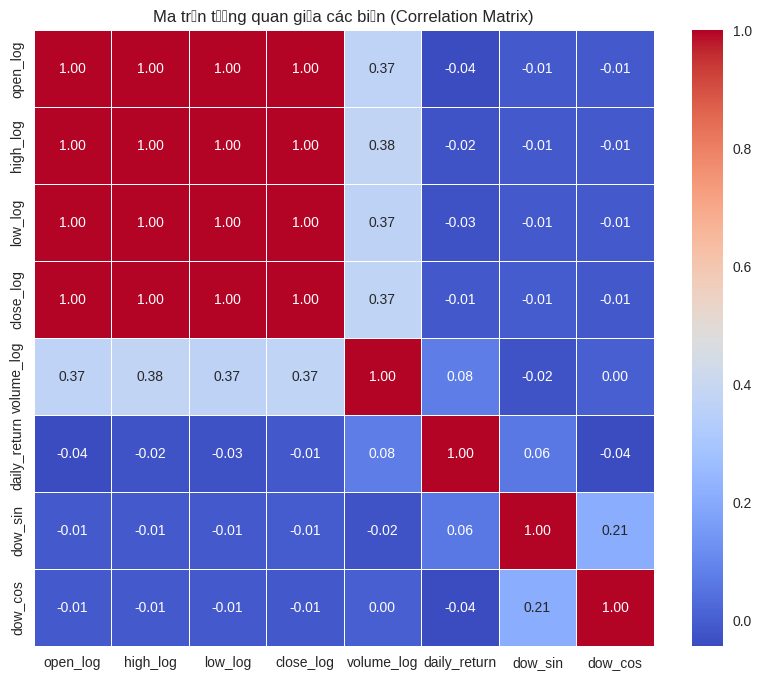

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chọn các cột bạn muốn kiểm tra (đã có trong df_processed)
features = ['open_log', 'high_log', 'low_log', 'close_log', 'volume_log', 'daily_return', 'dow_sin', 'dow_cos']

# 1. Tính toán ma trận tương quan
# .corr() mặc định dùng phương pháp Pearson (đo lường mối quan hệ tuyến tính)
corr_matrix = df_processed[features].corr()

# 2. In ra mức độ ảnh hưởng cụ thể đến 'close_log'
# Sắp xếp giảm dần để thấy cái nào ảnh hưởng nhất ở trên cùng
print("--- Mức độ tương quan với close_log ---")
print(corr_matrix['close_log'].sort_values(ascending=False))

# 3. Vẽ biểu đồ Heatmap cho trực quan
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,       # Hiển thị số lên ô
            cmap='coolwarm',  # Màu: Đỏ là tương quan dương mạnh, Xanh là âm
            fmt=".2f",        # Làm tròn 2 số thập phân
            linewidths=0.5)
plt.title("Ma trận tương quan giữa các biến (Correlation Matrix)")
plt.show()

In [10]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
# Giả định pd và Dataset đã được import



class MultivariateTimeSeriesDataset(Dataset):
    """
    Tạo các cửa sổ chuỗi thời gian (x: seq_len, y: pred_len)
    """
    def __init__(self, df: pd.DataFrame, seq_len: int, pred_len: int, 
                 target_cols: list, feature_cols: list, 
                 normalize: bool = False): # GIỮ NGUYÊN False để dùng RevIN
        
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.normalize = normalize
        
        self.data = df.copy()
        self.feature_cols = feature_cols
        self.target_cols = target_cols
        
        # --- Chuẩn hóa (Bị bỏ qua vì normalize=False) ---
        if self.normalize:
             # Logic chuẩn hóa toàn cục (Global Normalization) 
             # Phần này không chạy nên giữ nguyên
            self.scaler = {}
            all_cols = list(set(self.feature_cols + self.target_cols))
            for col in all_cols:
                mean = self.data[col].mean()
                std = self.data[col].std()
                self.scaler[col] = {'mean': mean, 'std': std}
                if std != 0:
                    self.data[col] = (self.data[col] - mean) / std
                else:
                    self.data[col] = 0 
        else:
            self.scaler = None

        self.feature_data = self.data[self.feature_cols].values.astype(np.float32)
        self.target_data = self.data[self.target_cols].values.astype(np.float32)
        
        self.num_features = self.feature_data.shape[1] 
        self.num_targets = len(self.target_cols)

    def __len__(self):
        # Số lượng cửa sổ có thể tạo: Length - seq_len - pred_len + 1
        return len(self.feature_data) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx: int):
        # x: [idx -> idx + seq_len]
        x = self.feature_data[idx : idx + self.seq_len]
        # y: [idx + seq_len -> idx + seq_len + pred_len]
        y = self.target_data[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        
        return torch.FloatTensor(x), torch.FloatTensor(y)

def create_datasets(df, seq_lengths, pred_len, target_cols, feature_cols):
    datasets = {}
    for seq_len in seq_lengths:
        datasets[f'{seq_len}d'] = MultivariateTimeSeriesDataset(
            df=df,
            seq_len=seq_len,
            pred_len=pred_len,
            target_cols=target_cols,
            feature_cols=feature_cols,
            normalize=False # Chuẩn hóa cục bộ (RevIN) sẽ xử lý
        )
    return datasets


# ----------------------------------------------------
# ÁP DỤNG VÀ KHỞI TẠO (GIỮ NGUYÊN LOGIC CỦA BẠN)
# ----------------------------------------------------

# 3. Áp dụng
# (df phải được định nghĩa trước khi chạy)
# df_eng_lite = process_data_with_features_lite(df) 

# 4. Định nghĩa danh sách Features (Tinh gọn - Đã bao gồm daily_return)
feature_cols = [
    # Cơ bản (5)
    # 'open_log', 
    # 'high_log', 
    # 'low_log', 
    'volume_log', 
    'close_log',
    
    # Biến động & Lợi nhuận (2)
    'daily_return',
    
    # # Thời gian (2)
    'dow_sin', 'dow_cos'
]

target_col = ['close_log']

# 5. Tạo DataFrame cuối cùng
# df_processed = df_eng_lite[feature_cols].copy()
# df_processed = df_processed.dropna()

# --- KHỞI TẠO (Cần df_processed) ---
seq_lengths = [120, 240, 480]
pred_len = 100

datasets = create_datasets(
    df_processed, 
    seq_lengths, 
    pred_len, 
    target_cols=['close_log'], 
    feature_cols = feature_cols
)

# print(f"Số lượng features đầu vào: {len(feature_cols)}")
# print(f"Kích thước dữ liệu sau xử lý: {df_processed.shape}")

In [11]:
df_processed.head()


,time,open,high,low,close,volume,symbol,open_log,high_log,low_log,close_log,volume_log,daily_return,dow_sin,dow_cos
0,2020-08-03,19.07,19.63,19.03,19.63,1392200,FPT,2.948116,2.977059,2.946017,2.977059,14.146397,0.000000,0.000000,1.000000
1,2020-08-04,19.89,20.01,19.76,19.91,1051310,FPT,2.990217,2.996232,2.983660,2.991222,13.865549,0.014264,0.781831,0.623490
2,2020-08-05,19.89,20.16,19.78,20.10,1328520,FPT,2.990217,3.003700,2.984671,3.000720,14.099577,0.009543,0.974928,-0.222521
3,2020-08-06,20.10,20.21,19.97,20.01,1153660,FPT,3.000720,3.006178,2.994231,2.996232,13.958451,-0.004478,0.433884,-0.900969
4,2020-08-07,20.01,20.44,20.01,20.14,1283690,FPT,2.996232,3.017494,2.996232,3.002708,14.065250,0.006497,-0.433884,-0.900969


In [12]:
# CÁC LỚP Linear_M GIỮ NGUYÊN (ĐÃ ĐÚNG)
class Trend_MLP(nn.Module):
    def __init__(self, seq_len, pred_len, num_features, dropout=0.1):
        super(Trend_MLP, self).__init__()
        
        # 1. Dự đoán theo chiều thời gian (Time Mixing)
        # Linear layer này học mối quan hệ từ Seq_len -> Pred_len
        self.time_linear = nn.Linear(seq_len, pred_len)
        
        # 2. Activation (GELU hoặc ReLU) để tăng tính phi tuyến
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        
        # 3. Gộp Features (Feature Mixing): Từ 5 features -> 1 feature (Close)
        self.feature_linear = nn.Linear(num_features, 1)
        self.act1 = nn.GELU()

    def forward(self, x):
        # x: [Batch, Seq_len, Num_features]
        
        # Bước A: Xử lý chiều thời gian (như cũ)
        x = x.permute(0, 2, 1)        # [Batch, Num_features, Seq_len]
        x = self.time_linear(x)       # [Batch, Num_features, Pred_len]
        
        # Bước B: Activation
        x = self.act(x)
        x = self.dropout(x)
        
        # Bước C: Gộp Features
        x = x.permute(0, 2, 1)        # [Batch, Pred_len, Num_features]
        x = self.feature_linear(x)    # [Batch, Pred_len, 1] <- Đã ra 1 giá trị duy nhất
        x = self.act1(x)
        return x

# --- LỚP RevIN (ĐÃ TĂNG EPS) ---
class RevIN(nn.Module):
    """Reversible Instance Normalization (Chuẩn hóa cục bộ)"""
    # Tăng EPS lên 1e-4 để tăng tính ổn định số học
    def __init__(self, num_features: int, eps=1e-3, affine=True): 
        super(RevIN, self).__init__()
        self.num_features = num_features
        self.eps = eps
        self.affine = affine
        if self.affine:
            self._init_params()

    def _init_params(self):
        self.affine_weight = nn.Parameter(torch.ones(self.num_features))
        self.affine_bias = nn.Parameter(torch.zeros(self.num_features))

    def _get_statistics(self, x):
        dim2reduce = tuple(range(1, x.ndim - 1)) 
        self.mean = torch.mean(x, dim=dim2reduce, keepdim=True).detach()
        # stdev = sqrt(var + eps)
        self.stdev = torch.sqrt(torch.var(x, dim=dim2reduce, keepdim=True, unbiased=False) + self.eps).detach()

    def _normalize(self, x):
        x = x - self.mean
        x = x / self.stdev
        if self.affine:
            x = x * self.affine_weight
            x = x + self.affine_bias
        return x

    def _denormalize(self, x):
        if self.affine:
            x = x - self.affine_bias
            # Sử dụng eps đã tăng (1e-4) để ổn định
            x = x / (self.affine_weight + self.eps) 
        x = x * self.stdev
        x = x + self.mean
        return x

    def forward(self, x, mode:str):
        if mode == 'norm':
            self._get_statistics(x)
            x = self._normalize(x)
        elif mode == 'denorm':
            x = self._denormalize(x)
        return x


# === CẤU HÌNH ĐƠN GIẢN HÓA ===
D_MODEL_SIMPLE = 128
N_LAYERS_SIMPLE = 4
N_HEADS_SIMPLE = 4

class SimpleTransformer_Seasonal(nn.Module):
    """
    Sử dụng kiến trúc Transformer Encoder-Decoder tiêu chuẩn của PyTorch
    để dự đoán phần Seasonal, giảm thiểu tham số cho Fine-tuning.
    """
    def __init__(self, seq_len, pred_len, num_features, d_model, n_layers, n_heads, dropout=0.2):
        super(SimpleTransformer_Seasonal, self).__init__()
        self.seq_len = seq_len
        self.pred_len = pred_len
        self.num_features = num_features
        self.d_model = d_model
        
        # 1. Input Embedding: Ánh xạ số lượng features (C) thành chiều ẩn (D_MODEL)
        self.input_embedding = nn.Linear(num_features, d_model)
        
        # 2. Positional Encoding: Thêm thông tin vị trí vào chuỗi đầu vào
        # Tạo tham số học được cho Positional Encoding cho cả seq_len và pred_len
        self.position_encoding = nn.Parameter(torch.randn(1, seq_len + pred_len, d_model))

        # 3. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # 4. Transformer Decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=d_model * 4, dropout=dropout, batch_first=True
        )
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=n_layers)

        # 5. Decoder Query Token: Các token/vị trí tương ứng với pred_len cần dự đoán
        self.decoder_query_token = nn.Parameter(torch.randn(pred_len, d_model))


    def forward(self, seasonal_input):
        # seasonal_input.shape: (Batch, Seq_len, Features) -> (B, L, C)
        B, L, C = seasonal_input.shape
        
        # 1. Embedding và Positional Encoding cho Encoder
        enc_input = self.input_embedding(seasonal_input) # (B, L, D_MODEL)
        enc_input = enc_input + self.position_encoding[:, :L, :] 

        # 2. Encoder: Học biểu diễn ngữ cảnh từ dữ liệu Seasonal quá khứ
        encoder_output = self.transformer_encoder(enc_input) # Memory: (B, L, D_MODEL)
        
        # 3. Chuẩn bị Decoder Query
        # Decoder query là target tokens + Positional Encoding cho tương lai
        decoder_query = self.decoder_query_token.unsqueeze(0).repeat(B, 1, 1) # (B, Pred_len, D_MODEL)
        decoder_query = decoder_query + self.position_encoding[:, L:L+self.pred_len, :]

        # 4. Decoder: Dự đoán Pred_len tokens dựa trên Memory (Output của Encoder)
        decoder_output = self.transformer_decoder(
            tgt=decoder_query, 
            memory=encoder_output
        ) # (B, Pred_len, D_MODEL)

        # Trả về output D_MODEL. Layer Projection bên ngoài sẽ ánh xạ về C
        return decoder_output
# --- LỚP DAutoformer_M (Cấu hình giữ nguyên D_MODEL=128) ---
class DAutoformer_M_TargetFocused(nn.Module):
    def __init__(self, seq_len, pred_len=5, num_features=5, moving_avg=7, d_model=64):
        super(DAutoformer_M_TargetFocused, self).__init__()
        
        # --- 1. RevIN và Decomp (Giữ nguyên) ---
        self.revin = RevIN(num_features) 
        
        # Tính Kernel cho Moving Average
        safe_moving_avg = min(moving_avg, seq_len)
        if safe_moving_avg % 2 == 0: safe_moving_avg -= 1
        self.moving_avg = max(1, safe_moving_avg)
        self.register_buffer('avg_kernel', torch.ones(num_features, 1, self.moving_avg) / self.moving_avg)
        
        # --- 2. Trend Branch (ĐÃ ĐỔI: Dùng MLP trả về 1 feature) ---
        self.trend_model = Trend_MLP(seq_len, pred_len, num_features)
        
        # --- 3. Seasonal Branch (Transformer) ---
        self.seasonal_model = SimpleTransformer_Seasonal(
            seq_len=seq_len, pred_len=pred_len, num_features=num_features,
            d_model=d_model, n_layers=1, n_heads=2, dropout=0.2
        )
        self.act = nn.GELU()
        # --- 4. Projection (ĐÃ ĐỔI: Output ra 1 feature thay vì num_features) ---
        self.projection = nn.Linear(d_model, 1) 

    def decompose(self, x):
        # ... (Code decompose y hệt cũ) ...
        x_permuted = x.permute(0, 2, 1)
        padding = (self.moving_avg - 1) // 2
        trend = F.conv1d(x_permuted, self.avg_kernel, padding=padding, groups=self.revin.num_features)
        trend = trend.permute(0, 2, 1)
        seasonal = x - trend
        return trend, seasonal

    def forward(self, x, target_idx):
        """
        target_idx (int): Index của cột muốn dự đoán (Close_log) để Denormalize đúng.
        """
        # 1. Normalize (Đầu vào vẫn là 5 cột)
        # RevIN sẽ lưu mean/std của cả 5 cột
        x = self.revin(x, 'norm') 
        
        # 2. Decompose
        trend_input, seasonal_input = self.decompose(x)
        
        # 3. Trend Branch -> Trả về [Batch, Pred, 1]
        trend_pred = self.trend_model(trend_input)
        
        # 4. Seasonal Branch -> Trả về [Batch, Pred, 1]
        seasonal_base = self.seasonal_model(seasonal_input)
        seasonal_pred = self.projection(seasonal_base) # Project d_model -> 1
        trend_pred = self.act(trend_pred)
        # 5. Combine
        final_pred = trend_pred + seasonal_pred # Shape: [Batch, Pred, 1]
        
        # 6. MANUAL DENORMALIZATION (Quan trọng!)
        # Vì final_pred chỉ có 1 cột, ta không dùng self.revin(final_pred, 'denorm') được.
        # Ta phải lấy thủ công Mean và Std của đúng cột target_idx.
        
        # self.revin.mean shape: [1, 1, 5] -> Lấy [:, :, target_idx] -> [1, 1, 1]
        target_mean = self.revin.mean[:, :, target_idx:target_idx+1]
        target_stdev = self.revin.stdev[:, :, target_idx:target_idx+1]
        
        if self.revin.affine:
            # Denorm công thức: (x - bias) / weight * stdev + mean
            target_bias = self.revin.affine_bias[target_idx]
            target_weight = self.revin.affine_weight[target_idx]
            final_pred = final_pred - target_bias
            final_pred = final_pred / (target_weight + self.revin.eps)
            
        final_pred = final_pred * target_stdev + target_mean
        
        return final_pred

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import TimeSeriesSplit
import matplotlib.pyplot as plt
import torch.nn.functional as F

# --- 1. Cấu hình Hyperparameters ---
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 150
PRED_LEN = pred_len # Đảm bảo biến này đã được định nghĩa bên ngoài
N_SPLITS = 5
PATIENCE = 15 

# Cấu hình thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- 2. Các hàm tiện ích (Train/Eval) - ĐÃ CẬP NHẬT TARGET_IDX ---
def train_one_epoch(model, train_loader, criterion, optimizer, device, target_idx):
    model.train()
    total_loss = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        
        # Truyền target_idx vào model để nó biết cột nào là Close mà Denormalize
        outputs = model(x, target_idx=target_idx)
        
        loss = criterion(outputs, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

def evaluate(model, val_loader, criterion, device, target_idx):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            
            # Truyền target_idx vào model
            outputs = model(x, target_idx=target_idx)
            
            loss = criterion(outputs, y)
            total_loss += loss.item()
    return total_loss / len(val_loader)

# --- CẤU HÌNH ROLLING WINDOW ---
MAX_TRAIN_SIZE = 365 
N_SPLITS = 5
# ---

# --- 3. Vòng lặp Huấn luyện ROLLING WINDOW (ĐÃ SỬA) ---
print(f"=== BẮT ĐẦU HUẤN LUYỆN DAutoformer (TargetFocused) VỚI ROLLING WINDOW ({MAX_TRAIN_SIZE} SAMPLES) ===")

best_models = {}
cv_results = {}
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

# Duyệt qua từng loại cửa sổ (50d, 45d...)
for seq_name, dataset in datasets.items():
    print(f"\n{'='*40}")
    print(f"Sequence Length: {seq_name} | Total Samples: {len(dataset)}")
    
    # --- QUAN TRỌNG: Tìm Index của 'close_log' trong feature list của dataset ---
    # Giả sử dataset.feature_cols là list ['open_log', 'high_log', ..., 'close_log', ...]
    try:
        CLOSE_IDX = dataset.feature_cols.index('close_log')
        print(f"-> Target 'close_log' found at index: {CLOSE_IDX}")
    except ValueError:
        raise ValueError("Không tìm thấy cột 'close_log' trong feature_cols của Dataset!")

    fold_metrics = []
    indices = np.arange(len(dataset))
    
    # Bắt đầu vòng lặp các Fold
    for fold, (train_idx, val_idx) in enumerate(tscv.split(indices)):
        
        # Chỉ lấy MAX_TRAIN_SIZE mẫu dữ liệu gần nhất
        if len(train_idx) > MAX_TRAIN_SIZE:
            train_idx = train_idx[-MAX_TRAIN_SIZE:]
        
        print(f"\n  --- Fold {fold+1}/{N_SPLITS} (Rolling) ---")
        print(f"  Train size: {len(train_idx)} (Last {MAX_TRAIN_SIZE}) | Val size: {len(val_idx)}")
        
        # 1. Tạo Subset và DataLoader
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)
        
        train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)
        
        # 2. Khởi tạo lại Model (Sử dụng DAutoformer_M_TargetFocused MỚI NHẤT)
        model = DAutoformer_M_TargetFocused( 
            seq_len=dataset.seq_len,
            pred_len=PRED_LEN,
            num_features=dataset.num_features, # Vẫn là 5 (hoặc số lượng features đầu vào)
            d_model=64 # Hoặc 32 tùy bạn chỉnh
        ).to(device)
        
        # 3. Optimizer & Loss & Scheduler
        criterion = nn.HuberLoss()
        optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
        
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.3, patience=PATIENCE, verbose=False 
        )
        
        # 4. Training Loop
        best_val_loss = float('inf')
        
        for epoch in range(EPOCHS):
            # Truyền CLOSE_IDX vào hàm train/eval
            train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, target_idx=CLOSE_IDX)
            val_loss = evaluate(model, val_loader, criterion, device, target_idx=CLOSE_IDX)
            
            scheduler.step(val_loss)
            
            if (epoch + 1) % 20 == 0: 
                current_lr = optimizer.param_groups[0]['lr']
                print(f"    Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f}")
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
        
        fold_metrics.append(best_val_loss)
        print(f"  -> Best Val Loss for Fold {fold+1}: {best_val_loss:.4f}")

        # Lưu model Fold cuối cùng
        if fold == N_SPLITS - 1:
            best_models[seq_name] = model

    avg_val_loss = np.mean(fold_metrics)
    cv_results[seq_name] = avg_val_loss
    print(f"\n  => ROLLING AVERAGE Val Loss for {seq_name}: {avg_val_loss:.4f}")

print("\n=== HUẤN LUYỆN HOÀN TẤT VỚI ROLLING WINDOW ===")
print("\nHiệu suất trung bình (Val Loss) trên các cấu hình:")
for name, loss in cv_results.items():
    print(f"- {name}: {loss:.4f}")

Using device: cuda
=== BẮT ĐẦU HUẤN LUYỆN DAutoformer (TargetFocused) VỚI ROLLING WINDOW (365 SAMPLES) ===

Sequence Length: 120d | Total Samples: 930
-> Target 'close_log' found at index: 1

  --- Fold 1/5 (Rolling) ---
  Train size: 155 (Last 365) | Val size: 155
    Epoch 20/150 | Train Loss: 0.0059 | Val Loss: 0.0083 | LR: 0.001000
    Epoch 40/150 | Train Loss: 0.0057 | Val Loss: 0.0083 | LR: 0.000090
    Epoch 60/150 | Train Loss: 0.0057 | Val Loss: 0.0083 | LR: 0.000027
    Epoch 80/150 | Train Loss: 0.0057 | Val Loss: 0.0083 | LR: 0.000008
    Epoch 100/150 | Train Loss: 0.0056 | Val Loss: 0.0083 | LR: 0.000002
    Epoch 120/150 | Train Loss: 0.0057 | Val Loss: 0.0083 | LR: 0.000000
    Epoch 140/150 | Train Loss: 0.0057 | Val Loss: 0.0083 | LR: 0.000000
  -> Best Val Loss for Fold 1: 0.0066

  --- Fold 2/5 (Rolling) ---
  Train size: 310 (Last 365) | Val size: 155
    Epoch 20/150 | Train Loss: 0.0049 | Val Loss: 0.0177 | LR: 0.001000
    Epoch 40/150 | Train Loss: 0.0045 | Va

In [14]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def recursive_predict_100_days_v4(model, initial_input, steps=100, feature_cols=None, n_simulations=50):
    """
    Dự báo 100 ngày bằng phương pháp Monte Carlo & Tạo nến giả lập.
    
    Args:
        model: Mô hình đã train (DAutoformer).
        initial_input: Tensor input ban đầu [1, seq_len, num_features].
        steps: Số ngày cần dự báo (100).
        feature_cols: List tên các cột (để xác định index).
        n_simulations: Số lần chạy mô phỏng (càng cao càng mượt, khuyến nghị 20-50).
    
    Returns:
        mean_forecast: Dự báo trung bình (Log scale).
        upper_bound: Dải trên 90% (Log scale).
        lower_bound: Dải dưới 10% (Log scale).
    """
    model.eval()
    device = next(model.parameters()).device
    
    # 1. Map Index các features
    try:
        close_idx = feature_cols.index('close_log')
        # Tìm các cột khác nếu có, nếu không thì gán index giả định
        vol_idx = feature_cols.index('volume_log') if 'volume_log' in feature_cols else -1
        # Các cột Open/High/Low có thể không có trong feature_cols rút gọn của bạn
        # Nếu không có, ta sẽ giả lập dựa trên Close
    except ValueError:
        print("Lỗi: Không tìm thấy 'close_log' trong feature_cols.")
        return None, None, None

    # 2. Tính thống kê lịch sử từ Input ban đầu (để tạo nhiễu hợp lý)
    current_input = initial_input.clone().to(device)
    # Lấy chuỗi giá đóng cửa lịch sử (dạng log)
    hist_close = current_input[0, :, close_idx].cpu().numpy()
    
    # Tính độ lệch chuẩn của lợi nhuận (Volatility)
    hist_diff = np.diff(hist_close)
    std_volatility = np.std(hist_diff) if len(hist_diff) > 0 else 0.02
    
    # Tính trung bình Volume (nếu có)
    mean_vol = 0
    if vol_idx != -1:
        hist_vol = current_input[0, :, vol_idx].cpu().numpy()
        mean_vol = np.mean(hist_vol)

    print(f"Bắt đầu mô phỏng {n_simulations} kịch bản (Volatility: {std_volatility:.4f})...")
    
    # Mảng chứa kết quả của tất cả các lần mô phỏng [simulations, steps]
    all_sim_paths = np.zeros((n_simulations, steps))

    for sim in range(n_simulations):
        # Reset input cho mỗi lần chạy
        sim_input = initial_input.clone().to(device)
        
        for i in range(steps):
            with torch.no_grad():
                # --- A. Model Predict ---
                # Model trả về [Batch, Pred_Len, 1]
                pred_out = model(sim_input, target_idx=close_idx)
                
                # Lấy giá trị dự báo đầu tiên của chuỗi Pred_Len (Step-by-step rolling)
                # Hoặc lấy giá trị cuối cùng nếu model chỉ predict 1 step.
                # Ở đây ta lấy step đầu tiên của output để cuốn chiếu từng ngày.
                pred_val = pred_out[0, 0, 0].item()

                # --- B. Thêm Nhiễu (Stochastic Noise) ---
                # Giúp mô hình không bị hội tụ về đường thẳng
                # Random noise theo phân phối chuẩn N(0, std)
                noise = np.random.normal(0, std_volatility)
                
                # Lấy giá trị đóng cửa phiên trước
                last_close_val = sim_input[0, -1, close_idx].item()
                
                # Áp dụng nhiễu: Giá dự báo = Giá model + Nhiễu
                # (Có thể giảm nhiễu theo thời gian nếu muốn conservative)
                pred_val_stochastic = pred_val + noise

                # --- C. Clamping (Chống sốc giá ảo) ---
                # Không cho phép giá thay đổi quá 7% (biên độ sàn) một ngày so với hôm trước
                max_change = 0.07 
                delta = pred_val_stochastic - last_close_val
                if delta > max_change: pred_val_stochastic = last_close_val + max_change
                elif delta < -max_change: pred_val_stochastic = last_close_val - max_change
                
                # Lưu kết quả
                all_sim_paths[sim, i] = pred_val_stochastic

                # --- D. Tạo Input mới (Synthetic Candle) ---
                # Ta cần tạo 1 dòng dữ liệu mới [1, 1, num_features] để nối vào đuôi
                next_input_row = sim_input[0, -1, :].clone().unsqueeze(0).unsqueeze(0) # [1, 1, F]
                
                # 1. Update Close
                next_input_row[0, 0, close_idx] = pred_val_stochastic
                
                # 2. Update Volume (Nếu có)
                # Logic: Giá biến động mạnh -> Volume tăng
                if vol_idx != -1:
                    vol_shock = np.random.normal(0, 0.5) # Nhiễu volume
                    # Volume biến động quanh mức trung bình
                    next_vol = mean_vol + vol_shock
                    next_input_row[0, 0, vol_idx] = next_vol
                
                # 3. Update các features khác (như daily_return)
                # Nếu có cột daily_return, phải tính lại
                if 'daily_return' in feature_cols:
                    ret_idx = feature_cols.index('daily_return')
                    # daily_return log space ~ diff of logs
                    next_ret = pred_val_stochastic - last_close_val 
                    next_input_row[0, 0, ret_idx] = next_ret

                # --- E. Sliding Window ---
                # Bỏ ngày cũ nhất (index 0), nối ngày mới vào (index -1)
                # sim_input: [1, seq_len, F] -> cắt [:, 1:, :] -> nối next_input_row
                sim_input = torch.cat([sim_input[:, 1:, :], next_input_row], dim=1)

    # 3. Tổng hợp kết quả (Ensemble)
    mean_forecast = np.mean(all_sim_paths, axis=0)
    upper_bound = np.percentile(all_sim_paths, 90, axis=0) # Dải trên 90%
    lower_bound = np.percentile(all_sim_paths, 10, axis=0) # Dải dưới 10%

    return mean_forecast, upper_bound, lower_bound

=== BẮT ĐẦU DỰ BÁO VỚI 3 MODELS ===

>> Đang xử lý model: 120d...
Bắt đầu mô phỏng 50 kịch bản (Volatility: 0.0130)...


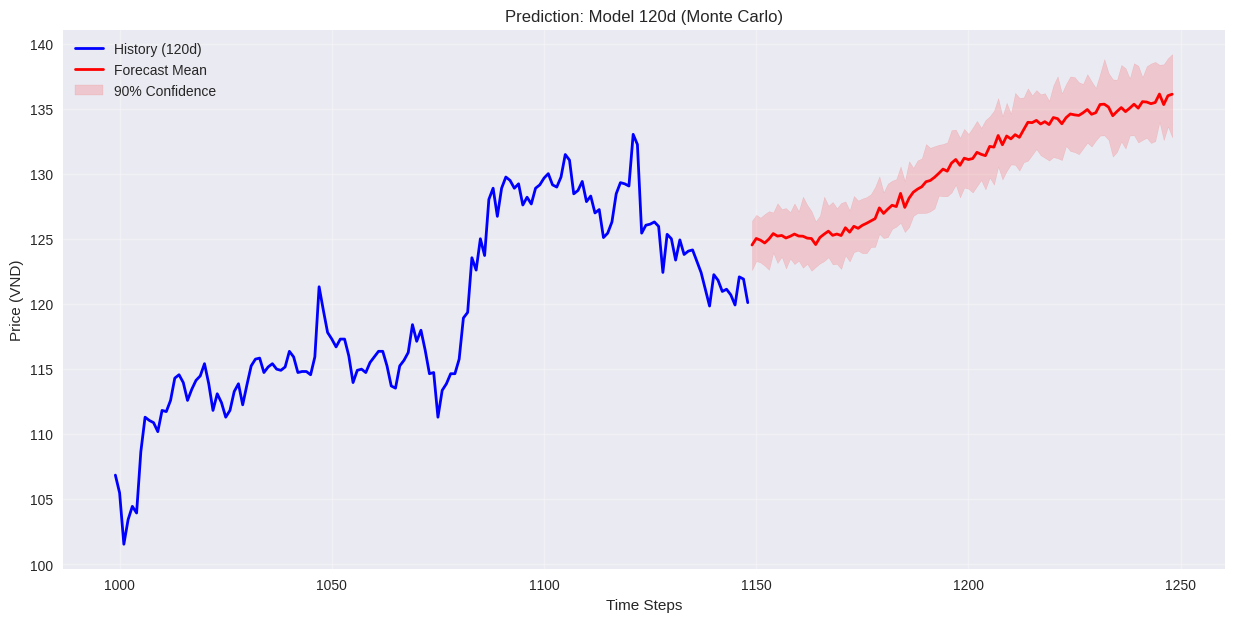

   [OK] Đã lưu: submission_120d_v4.csv

>> Đang xử lý model: 240d...
Bắt đầu mô phỏng 50 kịch bản (Volatility: 0.0153)...


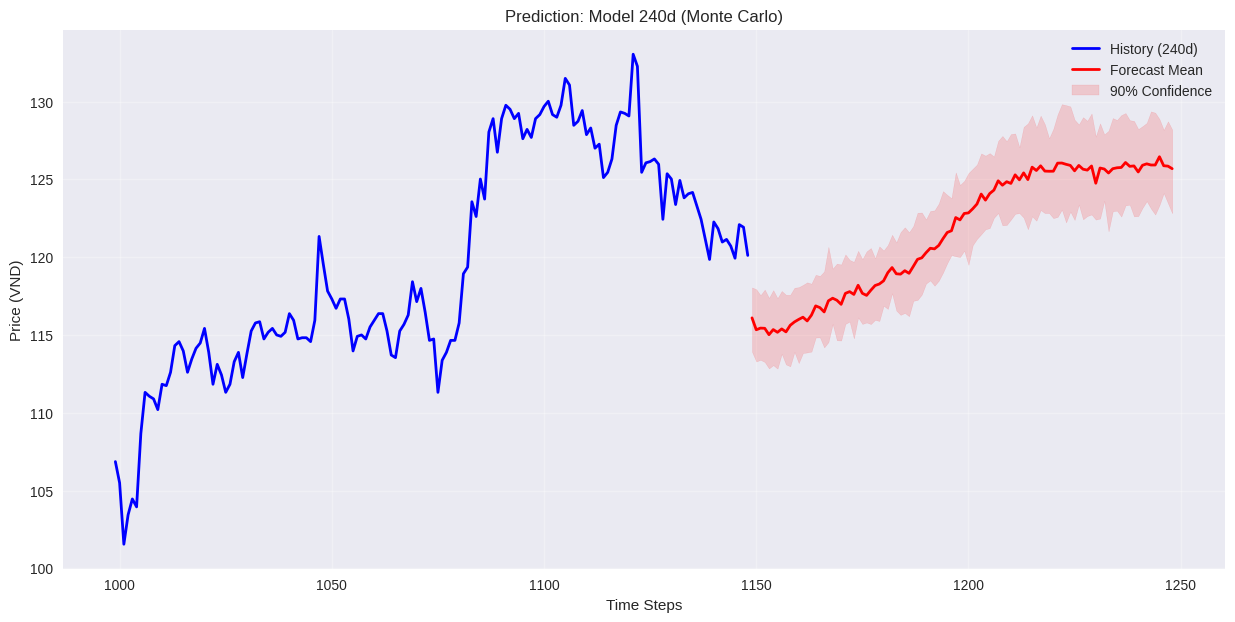

   [OK] Đã lưu: submission_240d_v4.csv

>> Đang xử lý model: 480d...
Bắt đầu mô phỏng 50 kịch bản (Volatility: 0.0143)...


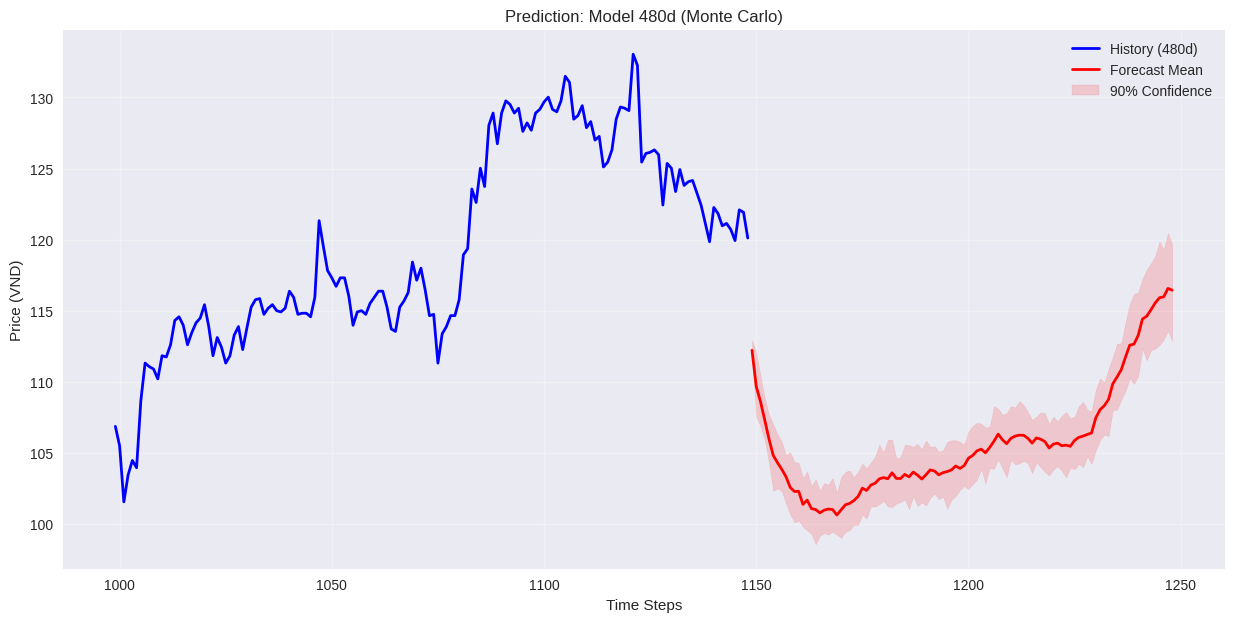

   [OK] Đã lưu: submission_480d_v4.csv

=== HOÀN TẤT TẤT CẢ ===


In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

# --- CẤU HÌNH DỰ BÁO ---
PREDICT_STEPS = 100
N_SIMULATIONS = 50

print(f"=== BẮT ĐẦU DỰ BÁO VỚI {len(best_models)} MODELS ===")

# Lặp qua từng model trong từ điển best_models
for seq_key, model_curr in best_models.items():
    print(f"\n>> Đang xử lý model: {seq_key}...")
    
    # Lấy dataset tương ứng
    if seq_key not in datasets:
        print(f"   Cảnh báo: Không tìm thấy dataset cho {seq_key}. Bỏ qua.")
        continue
        
    dataset_curr = datasets[seq_key]
    
    # Chuẩn bị dữ liệu đầu vào (chuỗi cuối cùng)
    last_seq_data = dataset_curr.feature_data[-dataset_curr.seq_len:]
    input_tensor = torch.FloatTensor(last_seq_data).unsqueeze(0).to(device)
    
    # --- GỌI HÀM DỰ BÁO V4 ---
    # Sử dụng hàm recursive_predict_100_days_v4 như code gốc của bạn
    forecast_log_mean, forecast_log_upper, forecast_log_lower = recursive_predict_100_days_v4(
        model=model_curr,
        initial_input=input_tensor,
        steps=PREDICT_STEPS,
        feature_cols=feature_cols, 
        n_simulations=N_SIMULATIONS            
    )
    
    # --- CHUYỂN ĐỔI LOG -> GIÁ THỰC ---
    pred_price_mean = np.exp(forecast_log_mean)
    pred_price_upper = np.exp(forecast_log_upper)
    pred_price_lower = np.exp(forecast_log_lower)
    
    # --- VẼ BIỂU ĐỒ ---
    plt.figure(figsize=(15, 7))
    
    # 1. Dữ liệu lịch sử
    history_len = 150
    close_col_idx = feature_cols.index('close_log')
    full_history_log = dataset_curr.feature_data[:, close_col_idx]
    full_history_price = np.exp(full_history_log)
    
    # Trục thời gian
    history_index = range(len(full_history_price) - history_len, len(full_history_price))
    future_index = range(len(full_history_price), len(full_history_price) + PREDICT_STEPS)
    
    plt.plot(history_index, full_history_price[-history_len:], label=f'History ({seq_key})', color='blue', linewidth=2)
    
    # 2. Dự báo
    plt.plot(future_index, pred_price_mean, label=f'Forecast Mean', color='red', linewidth=2)
    
    # 3. Vùng tin cậy
    plt.fill_between(future_index, pred_price_lower, pred_price_upper, color='red', alpha=0.15, label='90% Confidence')
    
    plt.title(f'Prediction: Model {seq_key} (Monte Carlo)')
    plt.xlabel('Time Steps')
    plt.ylabel('Price (VND)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # Hiển thị biểu đồ ngay lập tức
    
    # --- LƯU FILE CSV ---
    # Tên file động theo key của model
    filename = f'submission_{seq_key}_v4.csv'
    
    submission = pd.DataFrame({
        'id': range(1, PREDICT_STEPS + 1), 
        'close': pred_price_mean
    })
    submission.to_csv(filename, index=False)
    print(f"   [OK] Đã lưu: {filename}")

print("\n=== HOÀN TẤT TẤT CẢ ===")

In [16]:
import numpy as np
import torch
import math

def predict_block_recursive(model, initial_input, steps=100, feature_cols=None):
    """
    Dự báo cuốn chiếu theo Block (Chunk) để giảm thiểu sai số tích lũy.
    Thay vì lặp 100 lần, ta chỉ lặp khoảng 100/pred_len lần (ví dụ: 4 lần).
    """
    model.eval()
    device = next(model.parameters()).device
    
    # 1. Xác định Index các features
    try:
        close_idx = feature_cols.index('close_log')
        vol_idx = feature_cols.index('volume_log')
        ret_idx = feature_cols.index('daily_return')
    except ValueError:
        print("Lỗi: Cần có đủ 'close_log', 'volume_log', 'daily_return' trong feature_cols")
        return None

    # 2. Setup
    # Lấy pred_len thực tế từ model (ví dụ 30)
    # Lưu ý: Class DAutoformer_M_TargetFocused của bạn cần có thuộc tính self.seasonal_model.pred_len 
    # hoặc bạn truyền cứng vào nếu nhớ (ở đây giả định model.seasonal_model.pred_len tồn tại)
    try:
        pred_len = model.seasonal_model.pred_len
    except:
        pred_len = 30 # Giá trị mặc định trong notebook của bạn
        
    current_input = initial_input.clone().to(device) # [1, seq_len, num_features]
    
    # Tính toán thống kê Volume từ quá khứ để giả lập cho tương lai
    hist_vol = current_input[0, :, vol_idx].cpu().numpy()
    mean_vol = np.mean(hist_vol)
    std_vol = np.std(hist_vol)
    
    all_predictions = []
    
    # Tính số lần cần lặp (Ví dụ: 100 ngày / 30 = 4 blocks)
    num_blocks = math.ceil(steps / pred_len)
    
    print(f"Bắt đầu dự báo Block-wise: {steps} ngày chia thành {num_blocks} blocks (mỗi block {pred_len} ngày)...")
    
    for i in range(num_blocks):
        with torch.no_grad():
            # --- A. Dự báo Block (30 ngày) ---
            # Model trả về: [1, pred_len, 1] (Giá Close_log)
            # Lưu ý: Cần đảm bảo model trả về đúng shape [1, pred_len, 1]
            block_pred = model(current_input, target_idx=close_idx) 
            
            # Chuyển về numpy để dễ xử lý
            block_pred_np = block_pred[0, :, 0].cpu().numpy() # Shape: [pred_len]
            
            # Nếu block cuối cùng dài hơn số ngày cần thiết, cắt bớt
            current_step = len(all_predictions)
            remaining_steps = steps - current_step
            if len(block_pred_np) > remaining_steps:
                block_pred_np = block_pred_np[:remaining_steps]
            
            # Lưu kết quả Close
            all_predictions.extend(block_pred_np)
            
            # Nếu đã đủ 100 ngày thì dừng
            if len(all_predictions) >= steps:
                break
                
            # --- B. Tạo Features giả lập cho Block này (để làm input cho vòng sau) ---
            # Chúng ta cần tạo tensor [1, pred_len, num_features]
            
            # 1. Lấy giá đóng cửa cuối cùng của input hiện tại (để tính return ngày đầu tiên của block)
            last_close_log = current_input[0, -1, close_idx].item()
            
            # Tạo mảng chứa full features cho block mới
            # Shape: [1, len(block_pred_np), num_features]
            next_block_features = torch.zeros(1, len(block_pred_np), len(feature_cols)).to(device)
            
            # Fill Close Log
            next_block_features[0, :, close_idx] = torch.tensor(block_pred_np).to(device)
            
            # Fill Daily Return
            # Return = Close_t - Close_{t-1}
            # Tạo chuỗi giá bao gồm giá cuối cùng của quá khứ + giá dự báo
            concat_prices = np.concatenate(([last_close_log], block_pred_np))
            block_returns = np.diff(concat_prices)
            next_block_features[0, :, ret_idx] = torch.tensor(block_returns).to(device)
            
            # Fill Volume Log
            # Logic: Volume biến động ngẫu nhiên quanh trung bình, có thể tăng nhẹ khi return lớn
            # Vol = Mean + Noise + k * abs(Return)
            vol_noise = np.random.normal(0, std_vol * 0.5, size=len(block_pred_np))
            block_vol = mean_vol + vol_noise + (np.abs(block_returns) * mean_vol * 5) # Hệ số 5 là giả định momentum
            next_block_features[0, :, vol_idx] = torch.tensor(block_vol).to(device)
            
            # --- C. Sliding Window (Cập nhật Input) ---
            # Input cũ: [seq_len] -> Cắt bỏ phần đầu, nối block mới vào đuôi
            # seq_len cũ
            seq_len = current_input.shape[1]
            block_len = next_block_features.shape[1]
            
            # Nối vào: [1, seq_len + block_len, F]
            extended_input = torch.cat([current_input, next_block_features], dim=1)
            
            # Cắt lấy seq_len cuối cùng: [1, seq_len, F]
            current_input = extended_input[:, -seq_len:, :]

    return np.array(all_predictions)

# --- CÁCH SỬ DỤNG ---
# Giả sử bạn đã có model_best, dataset_best, feature_cols
# feature_cols = ['volume_log', 'close_log', 'daily_return']

# forecast_log_block = predict_block_recursive(
#     model_best, 
#     input_tensor, 
#     steps=100, 
#     feature_cols=feature_cols
# )
# forecast_price_block = np.exp(forecast_log_block)

# Vẽ so sánh
# plt.plot(forecast_price_block, label='Block-wise Prediction (Less Error)', color='green')

MÔ HÌNH TỐT NHẤT: 240d (Val Loss: 0.0117) ===
Bắt đầu mô phỏng 50 kịch bản (Volatility: 0.0153)...


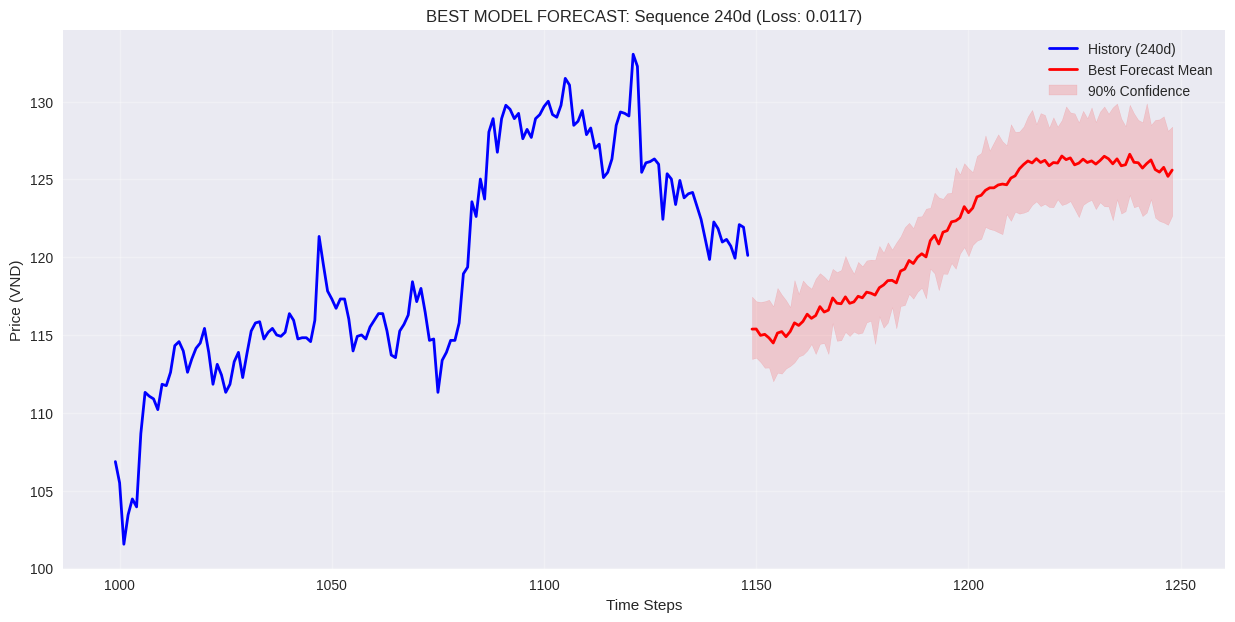

Đã lưu kết quả của mô hình tốt nhất vào: best_submission.csv


In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch

# --- CẤU HÌNH ---
PREDICT_STEPS = 100
N_SIMULATIONS = 50

# 1. TÌM MODEL TỐT NHẤT
# cv_results chứa { '120d': loss1, '240d': loss2 ... }
# Hàm min sẽ tìm key có value thấp nhất
best_seq_key = min(cv_results, key=cv_results.get)
best_val_loss = cv_results[best_seq_key]
best_model = best_models[best_seq_key]

print(f"MÔ HÌNH TỐT NHẤT: {best_seq_key} (Val Loss: {best_val_loss:.4f}) ===")

# 2. CHUẨN BỊ DỮ LIỆU INPUT CHO MODEL TỐT NHẤT
if best_seq_key in datasets:
    dataset_best = datasets[best_seq_key]
    
    # Lấy chuỗi dữ liệu cuối cùng để làm đầu vào dự báo
    last_seq_data = dataset_best.feature_data[-dataset_best.seq_len:]
    input_tensor = torch.FloatTensor(last_seq_data).unsqueeze(0).to(device)
    
    # 3. THỰC HIỆN DỰ BÁO (Sử dụng hàm Monte Carlo v4 của bạn)
    forecast_log_mean, forecast_log_upper, forecast_log_lower = recursive_predict_100_days_v4(
        model=best_model,
        initial_input=input_tensor,
        steps=PREDICT_STEPS,
        feature_cols=feature_cols, 
        n_simulations=N_SIMULATIONS            
    )
    
    # 4. CHUYỂN ĐỔI TỪ LOG VỀ GIÁ THỰC
    pred_price_mean = np.exp(forecast_log_mean)
    pred_price_upper = np.exp(forecast_log_upper)
    pred_price_lower = np.exp(forecast_log_lower)
    
    # 5. VẼ BIỂU ĐỒ KẾT QUẢ TỐT NHẤT
    plt.figure(figsize=(15, 7))
    
    # Lấy dữ liệu lịch sử để vẽ nối tiếp
    history_len = 150
    close_col_idx = feature_cols.index('close_log')
    full_history_log = dataset_best.feature_data[:, close_col_idx]
    full_history_price = np.exp(full_history_log)
    
    # Tạo trục thời gian
    history_index = range(len(full_history_price) - history_len, len(full_history_price))
    future_index = range(len(full_history_price), len(full_history_price) + PREDICT_STEPS)
    
    # Vẽ
    plt.plot(history_index, full_history_price[-history_len:], label=f'History ({best_seq_key})', color='blue', linewidth=2)
    plt.plot(future_index, pred_price_mean, label='Best Forecast Mean', color='red', linewidth=2)
    plt.fill_between(future_index, pred_price_lower, pred_price_upper, color='red', alpha=0.15, label='90% Confidence')
    
    plt.title(f'BEST MODEL FORECAST: Sequence {best_seq_key} (Loss: {best_val_loss:.4f})')
    plt.xlabel('Time Steps')
    plt.ylabel('Price (VND)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    # 6. LƯU FILE CSV DUY NHẤT (BEST SUBMISSION)
    submission_best = pd.DataFrame({
        'id': range(1, PREDICT_STEPS + 1), 
        'close': pred_price_mean
    })
    
    # Đặt tên file là best_submission.csv hoặc submission_best_model.csv
    filename = 'best_submission.csv'
    submission_best.to_csv(filename, index=False)
    print(f"Đã lưu kết quả của mô hình tốt nhất vào: {filename}")

else:
    print(f"Lỗi: Không tìm thấy dataset cho key {best_seq_key}")

In [ ]:
import dash
from dash import dcc, html, Input, Output, State, DiskcacheManager
import dash_bootstrap_components as dbc
import plotly.graph_objects as go
import pandas as pd
from pandas.tseries.offsets import BusinessDay
import os
import diskcache 
import importlib
from pyngrok import ngrok # [THÊM] Để chạy trên Kaggle


# 1. CẤU HÌNH BACKGROUND CALLBACK MANAGER
cache = diskcache.Cache("./cache_directory")
background_callback_manager = DiskcacheManager(cache)

# Input: Thay tên dataset của bạn vào đây
FILE_PATH_HISTORY = '/kaggle/input/aio-2025-linear-forecasting-challenge/FPT_train.csv' 
# Output: Kaggle bắt buộc ghi file ra thư mục working
FILE_PATH_PREDICTION = '/kaggle/working/best_submission.csv'

# 2. XỬ LÝ DỮ LIỆU & VẼ BIỂU ĐỒ (GIỮ NGUYÊN CODE CỦA BẠN)
def load_data_strict():
    if not os.path.exists(FILE_PATH_HISTORY):
        return None, None, f"LỖI: Không tìm thấy file input tại {FILE_PATH_HISTORY}"

    try:
        # --- Đọc Input ---
        df_hist = pd.read_csv(FILE_PATH_HISTORY)
        df_hist.columns = [c.lower().strip() for c in df_hist.columns]
        if 'time' in df_hist.columns: df_hist = df_hist.rename(columns={'time': 'Date'})
        rename_map = {'open': 'Open', 'high': 'High', 'low': 'Low', 'close': 'Close'}
        df_hist = df_hist.rename(columns=rename_map)
        df_hist['Date'] = pd.to_datetime(df_hist['Date'])
        df_hist = df_hist.sort_values('Date')

        # --- Đọc Output (Nếu chưa có file dự đoán thì trả về None ở phần này) ---
        if os.path.exists(FILE_PATH_PREDICTION):
            df_pred = pd.read_csv(FILE_PATH_PREDICTION)
            df_pred.columns = [c.lower().strip() for c in df_pred.columns]
            if 'close' not in df_pred.columns: df_pred['Close'] = df_pred.iloc[:, -1] 
            else: df_pred = df_pred.rename(columns={'close': 'Close'})
            
            # Fill ngày
            last_hist_date = df_hist['Date'].iloc[-1]
            future_dates = pd.bdate_range(start=last_hist_date + BusinessDay(1), periods=len(df_pred), freq='B')
            df_pred['Date'] = future_dates
        else:
            df_pred = pd.DataFrame() # Trả về rỗng nếu chưa train xong

        return df_hist, df_pred, "" 

    except Exception as e:
        return None, None, f"LỖI DỮ LIỆU: {str(e)}"

def create_chart(df_hist, df_pred):
    fig = go.Figure()

    # Nến Lịch sử
    fig.add_trace(go.Candlestick(
        x=df_hist['Date'], open=df_hist['Open'], high=df_hist['High'],
        low=df_hist['Low'], close=df_hist['Close'],
        name='Lịch sử'
    ))

    # Đường Dự đoán (Chỉ vẽ nếu có dữ liệu)
    if not df_pred.empty:
        last_hist_pt = df_hist.iloc[[-1]][['Date', 'Close']]
        pred_data = df_pred[['Date', 'Close']]
        line_data = pd.concat([last_hist_pt, pred_data])

        fig.add_trace(go.Scatter(
            x=line_data['Date'], y=line_data['Close'],
            mode='lines+markers', name='Dự đoán',
            line=dict(color='#00e5ff', width=2), marker=dict(size=3)
        ))
        
        # Vạch ngăn cách
        split_date = df_hist['Date'].iloc[-1]
        fig.add_vline(x=split_date, line_dash="dash", line_color="white")

    fig.update_xaxes(
        rangebreaks=[dict(bounds=["sat", "mon"])],
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1M", step="month", stepmode="backward"),
                dict(count=3, label="3M", step="month", stepmode="backward"),
                dict(step="all", label="All")
            ]),
            bgcolor="#333", font=dict(color="white"), activecolor="#00e5ff", y=1.05
        )
    )
    fig.update_layout(
        template='plotly_dark', height=600, dragmode='pan',
        margin=dict(l=30, r=30, t=80, b=30),
        legend=dict(orientation="h", y=1, x=0), hovermode='x unified'
    )
    return fig


# 3. GIAO DIỆN DASH (GIỮ NGUYÊN CODE CỦA BẠN)
app = dash.Dash(__name__, external_stylesheets=[dbc.themes.CYBORG], background_callback_manager=background_callback_manager)

app.layout = dbc.Container([
    # --- HEADER & CONTROLS ---
    dbc.Row([
        dbc.Col([
            html.Label("Mã CP:", className="fw-bold text-info"),
            dbc.Input(id="ticker", value="FPT", style={'font-weight': 'bold'}),
        ], width=2, className="mt-4"),
        
        dbc.Col([
            html.H2("CONQ007 - Stock Price Prediction", className="text-center mt-4 text-white"),
        ], width=5), # Giảm width từ 6 xuống 5 để nhường chỗ cho nút Clear

        # Khu vực nút bấm (Train + Clear)
        dbc.Col([
            dbc.Row([
                # Nút Train
                dbc.Col(dbc.Button("TRAIN MODEL", id="btn-train", color="danger", className="w-100 fw-bold"), width=8),
                # Nút Clear (Mới)
                dbc.Col(dbc.Button("CLEAR", id="btn-clear", color="secondary", className="w-100 fw-bold"), width=4),
            ]),
            
            # Thanh tiến trình (Progress Bar)
            html.Div([
                dbc.Progress(id="train-progress", value=0, striped=True, animated=True, className="mt-2", style={"height": "20px", "display": "none"}),
                html.Div(id="train-status", className="text-muted small mt-1 text-center")
            ])
        ], width=5, className="mt-4"), # Tăng width từ 4 lên 5
    ]),

    # --- ERROR MESSAGE ---
    dbc.Row(dbc.Col(html.Div(id="error-msg", className="text-danger fw-bold text-center mt-2"), width=12)),

    # --- MAIN CHART ---
    dbc.Row([
        dbc.Col([
            dbc.Card(
                dbc.CardBody(dcc.Loading(dcc.Graph(id='main-chart', config={'scrollZoom': True}), type="graph")),
                color="dark", outline=True
            )
        ], width=12, className="mt-3")
    ])
], fluid=True, style={'min-height': '100vh', 'background-color': '#000'})


# 4. CALLBACK BACKGROUND (GIỮ NGUYÊN CODE CỦA BẠN)
@app.callback(
    output=Output("train-status", "children"),
    inputs=Input("btn-train", "n_clicks"),
    background=True,
    running=[
        (Output("btn-train", "disabled"), True, False), # Disable nút Train khi đang chạy
        (Output("btn-clear", "disabled"), True, False), # Disable nút Clear khi đang chạy
        (Output("train-progress", "style"), {"display": "flex"}, {"display": "none"}), 
        (Output("train-progress", "value"), 100, 0), 
    ],
    prevent_initial_call=True
)
def run_training_process(n_clicks):
    import time
    if not model_train:
        return "Lỗi: Chưa tìm thấy file model_train.py"
    
    start_time = time.time()
    try:
        # GỌI HÀM MAIN() TỪ FILE MODEL CỦA BẠN
        print(">>> UI: Bắt đầu gọi lệnh Train...")
        model_train.main() 
        
        duration = round(time.time() - start_time, 2)
        return f"Train hoàn tất trong {duration}s. Dữ liệu đã cập nhật."
    except Exception as e:
        return f"Lỗi khi train: {str(e)}"


# 5. CALLBACK CẬP NHẬT BIỂU ĐỒ (GIỮ NGUYÊN CODE CỦA BẠN)
@app.callback(
    [Output('main-chart', 'figure'), Output('error-msg', 'children')],
    [Input('ticker', 'value'), Input('train-status', 'children'), Input('btn-clear', 'n_clicks')]
)
def update_chart(ticker, train_status, btn_clear):
    # Xác định nút nào vừa được bấm
    ctx = dash.callback_context
    if not ctx.triggered:
        trigger_id = 'No triggers'
    else:
        trigger_id = ctx.triggered[0]['prop_id'].split('.')[0]

    # TRƯỜNG HỢP BẤM CLEAR
    if trigger_id == 'btn-clear':
        empty = go.Figure()
        empty.update_layout(
            template='plotly_dark', 
            title="Dữ liệu đã được xóa",
            xaxis={"visible": False}, 
            yaxis={"visible": False}
        )
        return empty, "Đã xóa dữ liệu."

    # TRƯỜNG HỢP LOAD DỮ LIỆU BÌNH THƯỜNG
    # Check mã
    if not ticker or ticker.upper().strip() != 'FPT':
        empty = go.Figure()
        empty.update_layout(template='plotly_dark', title="Không có dữ liệu")
        return empty, "Hiện tại chỉ hỗ trợ mã FPT"

    # Load lại dữ liệu
    df_h, df_p, err_msg = load_data_strict()
    
    if err_msg:
        empty = go.Figure()
        empty.update_layout(template='plotly_dark', title="NO DATA")
        return empty, err_msg
    
    return create_chart(df_h, df_p), ""

# =============================================================================
# [SỬA ĐỔI DUY NHẤT 2] CHẠY SERVER BẰNG NGROK (BẮT BUỘC TRÊN KAGGLE)
# =============================================================================
# Thay Token của bạn vào bên dưới
NGROK_AUTH_TOKEN = ""  # Nhập token của bạn vào đây

if __name__ == '__main__':
    # Kill process cũ
    ngrok.kill()
    
    if NGROK_AUTH_TOKEN != "":
        ngrok.set_auth_token(NGROK_AUTH_TOKEN)
        
        # Mở kết nối Ngrok
        public_url = ngrok.connect(8050).public_url
        print(f"\nDASH APP ĐANG CHẠY TẠI: {public_url}\n")
        
        # Chạy Server: host='0.0.0.0' là bắt buộc trên Kaggle
        app.run(debug=False, port=8050, host='0.0.0.0')
    else:
        print("Vui lòng điền Ngrok Token để chạy app!")


🔥 DASH APP ĐANG CHẠY TẠI: https://gumptious-denyse-heptastyle.ngrok-free.dev

